# Day 10 - Halı Perspektif Düzeltme ve Homografi Analizi

Endüstriyel konveyör bandı üzerinde farklı açılardan yakalanan halı görüntülerinde otomatik 4 köşe tespiti, homografi dönüşümü ile perspektif düzeltme (rectification) ve geometrik doğrulama analizi.

> **Aşama:** Faz 2: Endüstriyel Görüntü İşleme (Day 10)  
> **Konu:** Perspektif Düzeltme, 8-DOF Homografi Matrisi ($3 \times 3$), Köşe Sıralama (`order_points`), Ortogonalite QA Değerlendirmesi  
> **Yazar:** Seydi Eryılmaz (@seydivakkas)  
> **Tarih:** 2026-09-05  
> **Lisans:** [Özel Lisans — Tüm Hakları Saklıdır](LICENSE)

---

In [1]:
import sys
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Dinamik ve güvenli kök dizin ekleme
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "day10" else CURRENT_DIR
DAY10_DIR = PROJECT_ROOT / "day10"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from day10.mini_project.src.corner_detector import CornerDetector, order_points
from day10.mini_project.src.homography import compute_homography, transform_points, warp_perspective
from day10.mini_project.src.rectifier import CarpetPerspectiveRectifier
from day10.mini_project.src.models import StandardCarpetRatio, QAGrade

print("Day 10 modülleri ve dizin yolları başarıyla yüklendi.")

Day 10 modülleri ve dizin yolları başarıyla yüklendi.


## Homografi Dönüşümü Öncesi ve Sonrası Karşılaştırması (Şekil 20)

Aşağıdaki panelde perspektifi bozulmuş sentetik halı görüntüsü (`carpet_skewed_oblique_25deg.png`), tespit edilen 4 köşe noktasının işaretlenmiş hali (`TL, TR, BR, BL`) ve homografi dönüşümü sonrası elde edilen düzeltilmiş dikdörtgen görüntü (`sample_rectified_carpet.png`) yan yana karşılaştırılmaktadır.

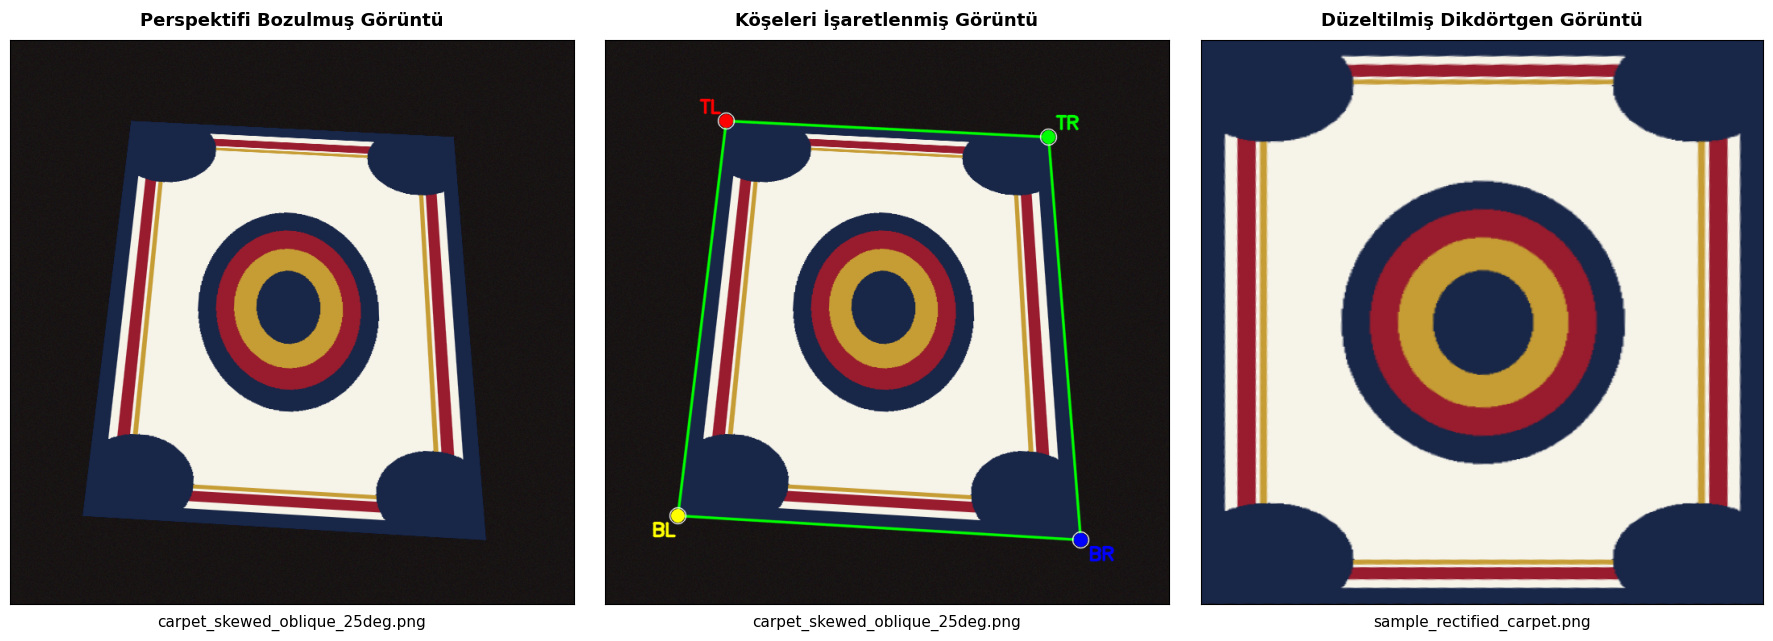

Rektifikasyon Başarılı: pass
Hedef Çözünürlük     : 501x502 px
Maksimum Açı Sapması : 0.00°


In [2]:
# Fikstür ve Çıktı Dizinleri
fixture_path = DAY10_DIR / "mini_project" / "fixtures" / "synthetic_carpets" / "carpet_skewed_oblique_25deg.png"
output_dir = DAY10_DIR / "mini_project" / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

# 1. Ham Görüntüyü Oku
raw_bytes = np.fromfile(str(fixture_path), dtype=np.uint8)
img_bgr = cv2.imdecode(raw_bytes, cv2.IMREAD_COLOR)

# 2. Köşeleri Tespit Et ve İşaretli Görseli Üret
detector = CornerDetector()
corners = detector.detect_corners(img_bgr)
overlay_bgr = detector.draw_corners_overlay(img_bgr, corners)

# 3. Perspektif Rektifikasyonu Uygula
rectifier = CarpetPerspectiveRectifier()
rectified_bgr, report = rectifier.rectify(img_bgr, corners=corners, mode="adaptive")

# Çıktıları outputs klasörüne kaydet
cv2.imwrite(str(output_dir / "carpet_skewed_oblique_25deg.png"), overlay_bgr)
cv2.imwrite(str(output_dir / "sample_rectified_carpet.png"), rectified_bgr)

# Şekil 20 Standardı 3'lü Panel Görselleştirmesi
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Perspektifi Bozulmuş Görüntü
axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Perspektifi Bozulmuş Görüntü", fontsize=13, fontweight="bold", pad=10)
axes[0].set_xlabel("carpet_skewed_oblique_25deg.png", fontsize=11, labelpad=8)
axes[0].set_xticks([])
axes[0].set_yticks([])

# 2. Köşeleri İşaretlenmiş Görüntü
axes[1].imshow(cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB))
axes[1].set_title("Köşeleri İşaretlenmiş Görüntü", fontsize=13, fontweight="bold", pad=10)
axes[1].set_xlabel("carpet_skewed_oblique_25deg.png", fontsize=11, labelpad=8)
axes[1].set_xticks([])
axes[1].set_yticks([])

# 3. Düzeltilmiş Dikdörtgen Görüntü
axes[2].imshow(cv2.cvtColor(rectified_bgr, cv2.COLOR_BGR2RGB))
axes[2].set_title("Düzeltilmiş Dikdörtgen Görüntü", fontsize=13, fontweight="bold", pad=10)
axes[2].set_xlabel("sample_rectified_carpet.png", fontsize=11, labelpad=8)
axes[2].set_xticks([])
axes[2].set_yticks([])

plt.tight_layout()
plt.show()

print(f"Rektifikasyon Başarılı: {report.qa_grade.value}")
print(f"Hedef Çözünürlük     : {report.target_dimensions[0]}x{report.target_dimensions[1]} px")
print(f"Maksimum Açı Sapması : {report.max_angle_deviation:.2f}°")

## Konveyör Bandı 35° Perspektif Köşe Tespiti (Şekil 19)

Fabrika konveyör bandı üzerinde simüle edilen $35^\circ$ açılı görüntü (`carpet_skewed_conveyor_35deg.png`) üzerinde 4 köşenin (TL, TR, BR, BL) hassas tespiti ve işaretlenmesi.

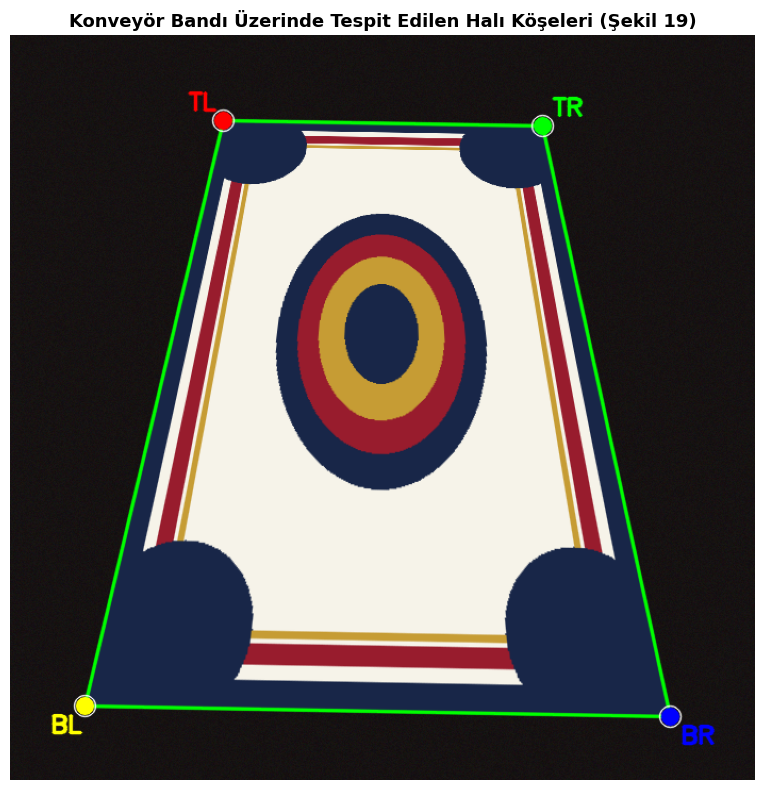

  TL: (200.0, 80.0)
  TR: (500.0, 85.0)
  BR: (620.0, 640.0)
  BL: (70.0, 630.0)


In [3]:
conveyor_path = DAY10_DIR / "mini_project" / "fixtures" / "synthetic_carpets" / "carpet_skewed_conveyor_35deg.png"
raw_bytes = np.fromfile(str(conveyor_path), dtype=np.uint8)
img_conveyor = cv2.imdecode(raw_bytes, cv2.IMREAD_COLOR)

corners_conveyor = detector.detect_corners(img_conveyor)
overlay_conveyor = detector.draw_corners_overlay(img_conveyor, corners_conveyor)
cv2.imwrite(str(output_dir / "carpet_skewed_conveyor_35deg.png"), overlay_conveyor)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(cv2.cvtColor(overlay_conveyor, cv2.COLOR_BGR2RGB))
ax.set_title("Konveyör Bandı Üzerinde Tespit Edilen Halı Köşeleri (Şekil 19)", fontsize=13, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

for i, lbl in enumerate(["TL", "TR", "BR", "BL"]):
    print(f"  {lbl}: ({corners_conveyor[i][0]:.1f}, {corners_conveyor[i][1]:.1f})")